<a href="https://colab.research.google.com/github/RyMack05/ML-fundamentals-2026/blob/main/assignment_1_Ryann_Mack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 – ML Fundamentals 2026

##Author: Ryann Mack

###Goal:
Given client and campaign information available at the time of contact, predict whether the client subscribes to a term deposit (i.e., a type of short-term investment)

### Overview

In this assignment, I use the UCI Bank Marketing dataset to predict whether a client subscribes to a term deposit (`y ∈ {yes, no}`), based only on information available at the time of contact.

### Main Objective

The goal is to correctly prepare the dataset so that a Logistic Regression model can be trained without methodological mistakes.

### Approach

* First, I identify the prediction target and analyze the dataset structure through EDA.
* Then, I split the data into training, validation, and test sets using stratification.
* All preprocessing steps (encoding, scaling, feature selection, imbalance handling) are applied only on the training set to avoid data leakage.
* Finally, I train a simple Logistic Regression model as a consistency check of the pipeline.

## Data Preparation Pipeline Overview

This assignment follows a strict preprocessing order to ensure methodological correctness and prevent data leakage.

1. **Target Identification**  
   Confirm y as the prediction target and define the prediction-time constraint.

2. **Exploratory Data Analysis (EDA)**  
   Analyze dataset structure, class imbalance, and identify suspicious variables. No transformations are applied at this stage.

3. **Stratified Data Splitting**  
   Split the dataset into 60% training, 20% validation, and 20% test sets.   Splitting is performed before any preprocessing to avoid leakage.

4. **Preprocessing (Training-Only Fitting)**  
   Handle missing values, encode categorical variables, and scale numerical features using parameters learned from the training set only.

5. **Feature Selection and Imbalance Handling**  
   Remove invalid or redundant features and address class imbalance using the training set only.

6. **Model Training and Evaluation**  
   Train a Logistic Regression model and evaluate performance using appropriate classification metrics.

## Target

In [53]:
# Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

We must predict whether a client subscribes to a term deposit given information available at the time of contact.

The natural target variable is the subscription outcome column (y).

In [54]:
url = "https://raw.githubusercontent.com/RyMack05/ML-fundamentals-2026/refs/heads/main/bank-additional.csv"

df = pd.read_csv(url, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


The column y represents whether the client subscribed to the term deposit (yes/no).

This matches the campaign goal described in the assignment, so we treat y as the prediction target.

In [55]:
# Check the unique values of the likely target column
df["y"].value_counts()

,count
y,
no,3668
yes,451


In [56]:
# Check the percentage of y/n of likely target column
df["y"].value_counts(normalize=True)

,proportion
y,
no,0.890507
yes,0.109493


## EDA

The dataset contains 4119 observations and 21 variables. Each row represents a client contacted during a marketing campaign.

In [57]:
df.shape

(4119, 21)

**Demographic attributes:**
* age
* job
* marital status
* education

**Financial attributes:**
* housing loan
* personal loan
* credit in default

Campaign-related attributes:
* contact type
* month and day of contact
* number of contacts performed during the campaign (campaign)
* number of days since last contact (pdays)
* number of previous contacts (previous)
* call duration (duration)

**Macroeconomic indicators:**
* employment variation rate (emp.var.rate)
* consumer price index (cons.price.idx)
* consumer confidence index (cons.conf.idx)
* Euribor 3-month rate (euribor3m)
* number of employees (nr.employed)

In [58]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Categorical variables are currently stored as object types and will require encoding before we train the model

In [59]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


**Categorical Variables to be encoded:**
* job
* marital
* education
* default
* housing
* loan
* contact
* month
* day_of_week
* poutcome
* y (target)

In [60]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

numerical_cols, categorical_cols

(Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome', 'y'],
       dtype='object'))

There are no explicit missing values (NaNs) in the dataset. However, implicit missing values such as "unknown" may still exist and must be examined.

In [61]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


The categorical variables:
* job
* marital
* education
* default
* housing
* loan

contain the value "unknown", which represents implicit missing information. These cases must be handled explicitly during preprocessing.

In [62]:
for col in categorical_cols:
    if "unknown" in df[col].unique():
        print(col)

job
marital
education
default
housing
loan


The age distribution appears right-skewed. Where most clients are concentrated around 30-40 years old. Past the age of about 60 we see a large decrease of customers, and some outliers around 80 to almost 90 years old.

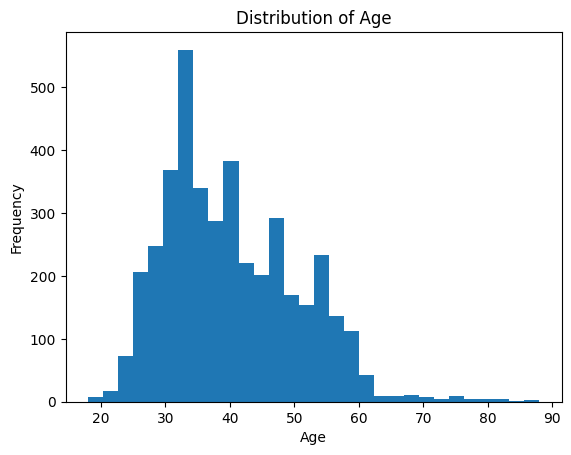

In [63]:
plt.hist(df["age"], bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The euribor3m variable forms clear clusters around approximately 1%, 4%, and 5%.

Euribor: Euro Interbank Offered Rate
* The average interest rate at which European banks lend money to each other

A Euriobor around 1% means
* Borrowing between banks is cheap
* Interest rates are low
* Savings products like term deposits may offer lower returns
* Clients may be less motivated to lock money

A Euriobor around 5% means
* Borrowing costs are high
* Interest rates are high
* Term deposits likely offer higher returns
* Clients may be more incentivized to subscribe

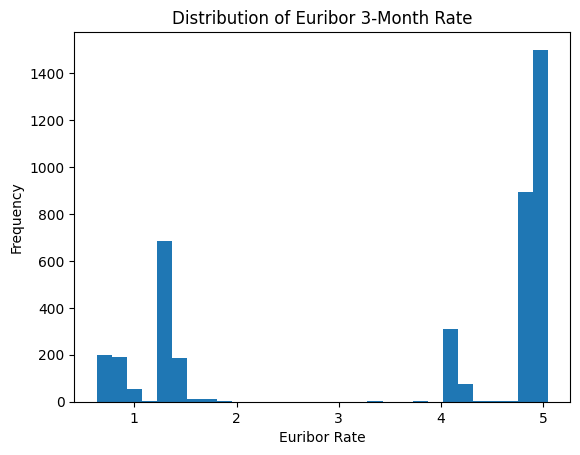

In [64]:
plt.hist(df["euribor3m"], bins=30)
plt.title("Distribution of Euribor 3-Month Rate")
plt.xlabel("Euribor Rate")
plt.ylabel("Frequency")
plt.show()

The job variable contains multiple categories with uneven distribution. Admin, Blue-Collar and Technician dominate the dataset, while from retired to unknown are much more rare. This will influence encoding and potential dimensionality expansion.

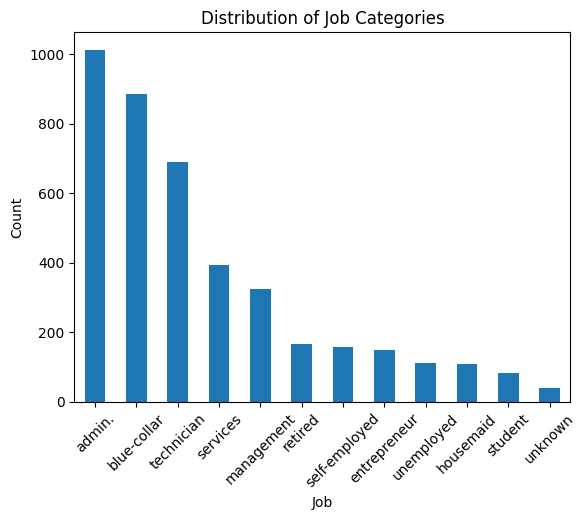

In [65]:
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of Job Categories")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Education levels are unevenly distributed, with university.degree and high.school dominating the dataset.

The variable has an inherent order, which will influence the encoding decision later.

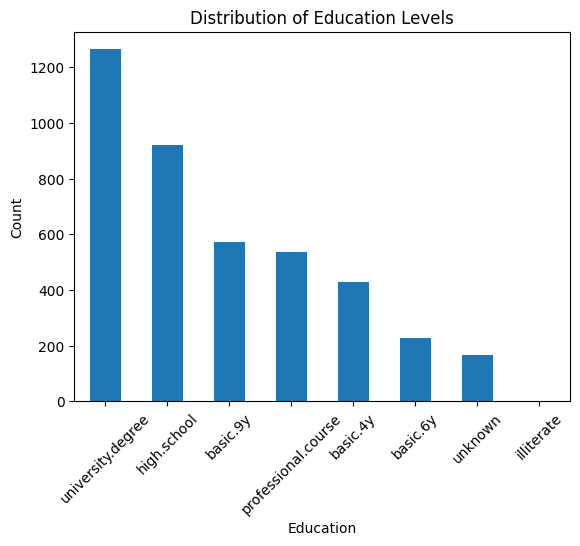

In [66]:
df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Levels")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Suspicious Variables
### duration: Temporal Leakage*

Call duration is only known after the conversation ends. It uses future information that would not be available at prediction time.

### poutcome: Target Leakage

Previous campaign outcome shows whether the client subscribed before. It directly contains target-related information rather than independent predictive features.


### pdays: Temporal / Behavioral Leakage

It may encode prior engagement patterns that are already related to subscription likelihood.

### previous: Proxy Leakage Risk

Number of previous contacts may indirectly reveal how interested a client was before. It acts as a proxy which indirectly carries target-related information.

### campaign: Adaptive Process Leakage

Campaign contact count may increase because earlier calls suggested interest. This means the feature can depend on evolving responses, not fixed client characteristics.


###Special Consideration Variable

I chose the variable **duration** because it is a clear example of temporal leakage. Duration is only known after the call ends.

Other campaign-related variables (poutcome, pdays, previous, campaign) may encode prior behavioral patterns related to subscription and must be carefully evaluated during feature selection.

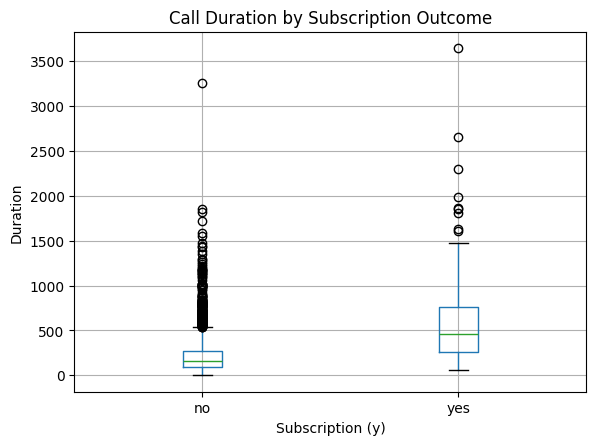

In [67]:
import matplotlib.pyplot as plt

df.boxplot(column="duration", by="y")
plt.title("Call Duration by Subscription Outcome")
plt.suptitle("")
plt.xlabel("Subscription (y)")
plt.ylabel("Duration")
plt.show()

## Train / Validation / Test Split
We use a 60% / 20% / 20% split:
- 60% Training
- 20% Validation
- 20% Test

We apply stratification on the target variable `y` to preserve class proportions across all splits. This is important because the dataset is imbalanced:

(~89% "no", ~11% "yes").

In [68]:
# "drop" y so we separate inputs and outputs
X = df.drop("y", axis=1)
y = df["y"]

In [69]:
# First split: create Training (60%) and Temporary (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,       # Preserve original class proportion
    random_state=42
)

In [70]:
# Second split: divide Temporary (40%) into Validation (20%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,    # Preserve original class proportion
    random_state=42
)

In [71]:
# Turn counts into proportions
print("Original distribution:")
print(y.value_counts(normalize=True))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Original distribution:
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Training distribution:
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Validation distribution:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test distribution:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


## Missing Values

We already know that there are unknown values in our variables

In [72]:
for col in categorical_cols:
    if "unknown" in df[col].unique():
        print(col)

job
marital
education
default
housing
loan


E.g.

In [73]:
df["job"].unique()

array(['blue-collar', 'services', 'admin.', 'entrepreneur',
       'self-employed', 'technician', 'management', 'student', 'retired',
       'housemaid', 'unemployed', 'unknown'], dtype=object)

### Handling unknown Values

The dataset contains the value "unknown" in several categorical variables
(job, marital, education, default, housing, loan).

Instead of imputing or removing them, we treat "unknown" as a separate category.

We will handle these values at the encoding step

##Encoding
We know the split of categorical and numerical.

We will separate them as nomial and ordinal variables

Nominal (one-hot encoding):
* job (technician 0/1 etc.)
* marital (married 0/1 etc.)
* default
* housing
* loan
* contact
* p_outcome

Ordinal (can do 0, 1, 2 etc. to each values):
* education
* month
* day_of_week

In [74]:
# Identify numerical and categorical columns using training set only
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

numerical_cols, categorical_cols

(Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome'],
       dtype='object'))

In [75]:
# Nominal categorical variables (no order)
categorical_nominal = [
    "job",
    "marital",
    "default",
    "housing",
    "loan",
    "contact",
    "poutcome"
]

# Ordinal categorical variables (natural order)
categorical_ordinal = [
    "education",
    "month",
    "day_of_week"
]

In [76]:
print("Nominal:", categorical_nominal)
print("Ordinal:", categorical_ordinal)

Nominal: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']
Ordinal: ['education', 'month', 'day_of_week']


In [88]:
from sklearn.preprocessing import OneHotEncoder

In [89]:
ohe = OneHotEncoder(drop="first", sparse_output=False)

In [90]:
# Fit encoder only on nominal training data
ohe.fit(X_train[categorical_nominal])

OneHotEncoder(drop='first', sparse_output=False)

In [91]:
# Transform training data to numeric
X_train_ohe = ohe.transform(X_train[categorical_nominal])

In [92]:
X_val_ohe = ohe.transform(X_val[categorical_nominal])
X_test_ohe = ohe.transform(X_test[categorical_nominal])

In [93]:
# Get column names created by encoder
ohe_columns = ohe.get_feature_names_out(categorical_nominal)

# Convert arrays to DataFrames
X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_val_ohe = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)